### load

In [1]:
import numpy as np
import polars as pl
from polars import selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler,FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector, TransformedTargetRegressor
from sklearn.model_selection import train_test_split,cross_validate,KFold
from sklearn.metrics import root_mean_squared_log_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
%matplotlib inline

from add_features import add_modified_features


In [2]:
train = pl.read_csv('../data/train.csv',infer_schema_length=None, null_values='NA')
test = pl.read_csv('../data/test.csv',infer_schema_length=None, null_values='NA')

print(train.shape, test.shape)

(1460, 81) (1459, 80)


In [3]:
X = train.select(cs.numeric() - cs.by_name('Id','SalePrice'))
y = train['SalePrice']

X_test = test.select(cs.numeric() - cs.by_name('Id'))
X.glimpse()

Rows: 1460
Columns: 36
$ MSSubClass    <i64> 60, 20, 60, 70, 60, 50, 20, 60, 50, 190
$ LotFrontage   <i64> 65, 80, 68, 60, 84, 85, 75, null, 51, 50
$ LotArea       <i64> 8450, 9600, 11250, 9550, 14260, 14115, 10084, 10382, 6120, 7420
$ OverallQual   <i64> 7, 6, 7, 7, 8, 5, 8, 7, 7, 5
$ OverallCond   <i64> 5, 8, 5, 5, 5, 5, 5, 6, 5, 6
$ YearBuilt     <i64> 2003, 1976, 2001, 1915, 2000, 1993, 2004, 1973, 1931, 1939
$ YearRemodAdd  <i64> 2003, 1976, 2002, 1970, 2000, 1995, 2005, 1973, 1950, 1950
$ MasVnrArea    <i64> 196, 0, 162, 0, 350, 0, 186, 240, 0, 0
$ BsmtFinSF1    <i64> 706, 978, 486, 216, 655, 732, 1369, 859, 0, 851
$ BsmtFinSF2    <i64> 0, 0, 0, 0, 0, 0, 0, 32, 0, 0
$ BsmtUnfSF     <i64> 150, 284, 434, 540, 490, 64, 317, 216, 952, 140
$ TotalBsmtSF   <i64> 856, 1262, 920, 756, 1145, 796, 1686, 1107, 952, 991
$ 1stFlrSF      <i64> 856, 1262, 920, 961, 1145, 796, 1694, 1107, 1022, 1077
$ 2ndFlrSF      <i64> 854, 0, 866, 756, 1053, 566, 0, 983, 752, 0
$ LowQualFinSF  <i64> 0, 0, 0, 

### explore

In [4]:
train.describe()

statistic,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,…,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
str,f64,f64,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,str,str,str,str,str,f64,str,str,str,str,str,str,str,f64,str,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,str,str,f64
"""count""",1460.0,1460.0,"""1460""",1201.0,1460.0,"""1460""","""91""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""",1460.0,1460.0,1460.0,1460.0,"""1460""","""1460""","""1460""","""1460""","""1452""",1452.0,"""1460""","""1460""","""1460""","""1423""","""1423""","""1422""","""1423""",1460.0,"""1422""",…,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,"""1460""",1460.0,"""1460""",1460.0,"""770""","""1379""",1379.0,"""1379""",1460.0,1460.0,"""1379""","""1379""","""1460""",1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,"""7""","""281""","""54""",1460.0,1460.0,1460.0,"""1460""","""1460""",1460.0
"""null_count""",0.0,0.0,"""0""",259.0,0.0,"""0""","""1369""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""8""",8.0,"""0""","""0""","""0""","""37""","""37""","""38""","""37""",0.0,"""38""",…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,"""0""",0.0,"""690""","""81""",81.0,"""81""",0.0,0.0,"""81""","""81""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""1453""","""1179""","""1406""",0.0,0.0,0.0,"""0""","""0""",0.0
"""mean""",730.5,56.89726,null,70.049958,10516.828082,null,null,null,null,null,null,null,null,null,null,null,null,6.099315,5.575342,1971.267808,1984.865753,null,null,null,null,null,103.685262,null,null,null,null,null,null,null,443.639726,null,…,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,null,6.517808,null,0.613014,null,null,1978.506164,null,1.767123,472.980137,null,null,null,94.244521,46.660274,21.95411,3.409589,15.060959,2.758904,null,null,null,43.489041,6.321918,2007.815753,null,null,180921.19589
"""std""",421.610009,42.300571,null,24.284752,9981.264932,null,null,null,null,null,null,null,null,null,null,null,null,1.382997,1.112799,30.202904,20.645407,null,null,null,null,null,181.066207,null,null,null,null,null,null,null,456.098091,null,…,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,null,1.625393,null,0.644666,null,null,24.689725,null,0.747315,213.804841,null,null,null,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,null,null,null,496.123024,2.703626,1.328095,null,null,79442.502883
"""min""",1.0,20.0,"""C (all)""",21.0,1300.0,"""Grvl""","""Grvl""","""IR1""","""Bnk""","""AllPub""","""Corner""","""Gtl""","""Blmngtn""","""Artery""","""Artery""","""1Fam""","""1.5Fin""",1.0,1.0,1872.0,1950.0,"""Flat""","""ClyTile""","""AsbShng""","""AsbShng""","""BrkCmn""",0.0,"""Ex""","""Ex""","""BrkTil""","""Ex""","""Fa""","""Av""","""ALQ""",0.0,"""ALQ""",…,0.0,0.0,334.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Ex""",2.0,"""Maj1""",0.0,"""Ex""","""2Types""",1900.0,"""Fin""",0.0,0.0,"""Ex""","""Ex""","""N""",0.0,0.0,0.0,0.0,0.0,0.0,"""Ex""","""GdPrv""","""Gar2""",0.0,1.0,2006.0,"""COD""","""Abnorml""",34900.0
"""25%""",366.0,20.0,null,59.0,7558.0,null,null,null,

In [5]:
nulls = train.select(cs.numeric()).to_pandas().isna().sum()
nulls[nulls > 0]

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

### pipeline

In [7]:
# Target-Pipeline
log_standardize_y = Pipeline([
    ("log", FunctionTransformer(np.log1p, inverse_func=np.expm1, check_inverse=False)),
    ("scale", StandardScaler())
])

# Features Pipeline
log_standardize = Pipeline([
    ("log", FunctionTransformer(np.log1p, inverse_func=np.expm1, check_inverse=False)),
    ("scale", StandardScaler())
])

### add modified feature

In [ ]:
X_train, X_va, y_train, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X = add_modified_features(X)
X_test = add_modified_features(X_test)

### cross validation

Fold 1: train RMSLE = 0.1344 / valid RMSLE = 0.1305
Fold 2: train RMSLE = 0.1289 / valid RMSLE = 0.1527
Fold 3: train RMSLE = 0.1232 / valid RMSLE = 0.1719
Fold 4: train RMSLE = 0.1364 / valid RMSLE = 0.1237
Fold 5: train RMSLE = 0.1381 / valid RMSLE = 0.1157
CV平均: train 0.1322 / valid 0.1389
最終スコア(test RMSLE): 0.1394


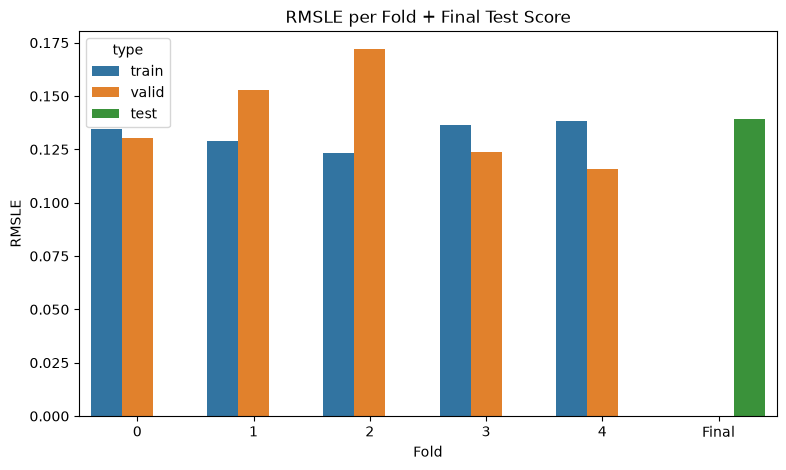

In [9]:
# base_model = Pipeline([
#     ("log_standard", log_standardize),
#     ("rfr", RandomForestRegressor(
#         n_estimators=200,
#         max_depth=5,
#         random_state=42,
#         n_jobs=-1))
# ])
base_model = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("log_standard", log_standardize),
    ("ridge", Ridge(alpha=10))
])
model = TransformedTargetRegressor(
    regressor=base_model,
    transformer=log_standardize_y,
    check_inverse=False
)

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)
result = cross_validate(
    model, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores = -result["train_score"]
valid_scores = -result["test_score"]

for i, (tr, va) in enumerate(zip(train_scores, valid_scores), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores.mean():.4f} / valid {valid_scores.mean():.4f}")

model.fit(X_train, y_train)
test_score = root_mean_squared_log_error(y_va, model.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score:.4f}")

# スコアグラフ
df = pl.DataFrame({
    "Fold": [str(i) for i in range(folds)] * 2 + ["Final"],
    "RMSLE": list(train_scores) + list(valid_scores) + [test_score],
    "type": ["train"] * folds + ["valid"] * folds + ["test"],
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Fold", y="RMSLE", hue="type")
plt.title("RMSLE per Fold + Final Test Score")
plt.show()


### submit

In [10]:
submit_df = pl.DataFrame({
    "Id": test['Id'],
    "SalePrice": model.predict(X_test)
})

In [11]:
submit_df.write_csv("../submit.csv")